imports and output formating


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.options.display.float_format ='{:20.2f}'.format

pd.set_option('display.max_columns',999)


<h1>DATA EXPLORATION</h1>

In [2]:
df=pd.read_excel("./online_retail_II.xlsx",sheet_name=0)

df.head(5)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


<h1>DATA DESCRIPTION AND METADATA<h1>

In [3]:
df.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845017856,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe( include='O')#only objects


,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


<h1>Taking care of miscellaneous data</h1>
<h2>->missing customer Ids</h2>
<h2>->negative quantity and negative price<h2>
<h2>->cancellations<h2>

In [6]:
df[df["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
df[df["Quantity"]<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.00,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.00,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.00,United Kingdom


In [8]:
df['Invoice']=df['Invoice'].astype("str")# settign as string to use regex
df[df["Invoice"].str.match("^\\d{6}$")==False] #^ used to say this must be start of our string ,$ used for exact 6

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.00,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.00,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.00,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.00,United Kingdom


In [9]:
df["Invoice"].str.replace("[0-9]","",regex=True).unique()

array(['', 'C', 'A'], dtype=object)

In [10]:
df[df["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [11]:
df['StockCode']=df['StockCode'].astype("str")# settign as string to use regex
df[df['StockCode'].str.match("^\\d{5}$")==False] #^ used to say this must be start of our string ,$ used for exact 5

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
12,489436,48173C,DOOR MAT BLACK FLOCK,10,2009-12-01 09:06:00,5.95,13078.00,United Kingdom
23,489436,35004B,SET OF 3 BLACK FLYING DUCKS,12,2009-12-01 09:06:00,4.65,13078.00,United Kingdom
28,489436,84596F,SMALL MARSHMALLOWS PINK BOWL,8,2009-12-01 09:06:00,1.25,13078.00,United Kingdom
...,...,...,...,...,...,...,...,...
525387,538170,84029E,RED WOOLLY HOTTIE WHITE HEART.,2,2010-12-09 19:32:00,3.75,13969.00,United Kingdom
525388,538170,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,2,2010-12-09 19:32:00,3.75,13969.00,United Kingdom
525389,538170,85232B,SET OF 3 BABUSHKA STACKING TINS,2,2010-12-09 19:32:00,4.95,13969.00,United Kingdom
525435,538171,47591D,PINK FAIRY CAKE CHILDRENS APRON,1,2010-12-09 20:01:00,1.95,17530.00,United Kingdom


In [12]:
stockcode=df[(df['StockCode'].str.match("^\\d{5}$")== False) & (df["StockCode"].str.match("^\\d{5}[A-Za-z]+$")==False)]["StockCode"].unique()

<h1>CHECKING THE SANCTITY OF STOCKCODES</h1>

In [13]:
for code in stockcode:
    print(df[df["StockCode"].str.contains(f"^{code}")==True].head(1))
    

   Invoice StockCode Description  Quantity         InvoiceDate  \
89  489439      POST     POSTAGE         3 2009-12-01 09:28:00   

                  Price          Customer ID Country  
89                18.00             12682.00  France  
     Invoice StockCode Description  Quantity         InvoiceDate  \
735  C489535         D    Discount        -1 2009-12-01 12:11:00   

                   Price          Customer ID         Country  
735                 9.00             15299.00  United Kingdom  
     Invoice StockCode       Description  Quantity         InvoiceDate  \
2377  489597  DCGS0058  MISO PRETTY  GUM         1 2009-12-01 14:28:00   

                    Price  Customer ID         Country  
2377                 0.83          NaN  United Kingdom  
     Invoice StockCode        Description  Quantity         InvoiceDate  \
2378  489597  DCGS0068  DOGS NIGHT COLLAR         1 2009-12-01 14:28:00   

                    Price  Customer ID         Country  
2378                 

<h1>DATA CLEANING</h1>

In [14]:
cleaned_df=df.copy()

cleaned_df.dropna(subset=["Customer ID"],inplace=True) #removing null customers

cleaned_df["StockCode"]=cleaned_df["StockCode"].astype("str")

mask=((cleaned_df["StockCode"].str.match("^\\d{5}$")==True)
      | (cleaned_df["StockCode"].str.match("^\\d{5}[A-Za-z]+$")==True)
      | (cleaned_df["StockCode"].str.match("^PADS$")==True)
      )

cleaned_df=cleaned_df[mask]

In [15]:
cleaned_df["Invoice"]=cleaned_df["Invoice"].astype("str")

mask=((cleaned_df["Invoice"].str.match("^\\d{6}$")==True))

cleaned_df=cleaned_df[mask]

In [16]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,406337.00,406337,406337.00,406337.00
mean,13.62,2010-07-01 10:11:06.543288320,2.99,15373.63
min,1.00,2009-12-01 07:45:00,0.00,12346.00
25%,2.00,2010-03-26 14:01:00,1.25,14004.00
50%,5.00,2010-07-09 15:48:00,1.95,15326.00
75%,12.00,2010-10-14 17:09:00,3.75,16814.00
max,19152.00,2010-12-09 20:01:00,295.00,18287.00
std,97.00,NaN,4.29,1677.37


In [17]:
len(cleaned_df)/len(df)

0.7732962103752705

DROPPED ABOUT 23%  of data

<H1>FEATURE ENGINEERING</H1>

In [18]:
cleaned_df["SalesLineTotal"]=cleaned_df["Price"]*cleaned_df["Quantity"]

cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.00,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.00,United Kingdom,7.50


In [19]:
aggregated_df= cleaned_df.groupby(by="Customer ID",as_index=False) \
    .agg(
        MonetaryValue=("SalesLineTotal","sum"),
        Frequency=("Invoice","nunique"),
        LastPurchaseDate=("InvoiceDate","max")
       )
    
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate
0,12346.00,169.36,2,2010-06-28 13:53:00
1,12347.00,1323.32,2,2010-12-07 14:57:00
2,12348.00,221.16,1,2010-09-27 14:59:00
3,12349.00,2221.14,2,2010-10-28 08:23:00
4,12351.00,300.93,1,2010-11-29 15:23:00


In [20]:
max_invoce_date=aggregated_df["LastPurchaseDate"].max()#used as basis for recency, ideally it should be taken from today.
min_invoce_date=aggregated_df["LastPurchaseDate"].min()

aggregated_df["Recency"]= (max_invoce_date - aggregated_df["LastPurchaseDate"]).dt.days# dt stands for datetime, days is used to get the difference in days
aggregated_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency
0,12346.00,169.36,2,2010-06-28 13:53:00,164
1,12347.00,1323.32,2,2010-12-07 14:57:00,2
2,12348.00,221.16,1,2010-09-27 14:59:00,73
3,12349.00,2221.14,2,2010-10-28 08:23:00,42
4,12351.00,300.93,1,2010-11-29 15:23:00,10


<h1>CHECKING FOR OUTLIERS</h1>

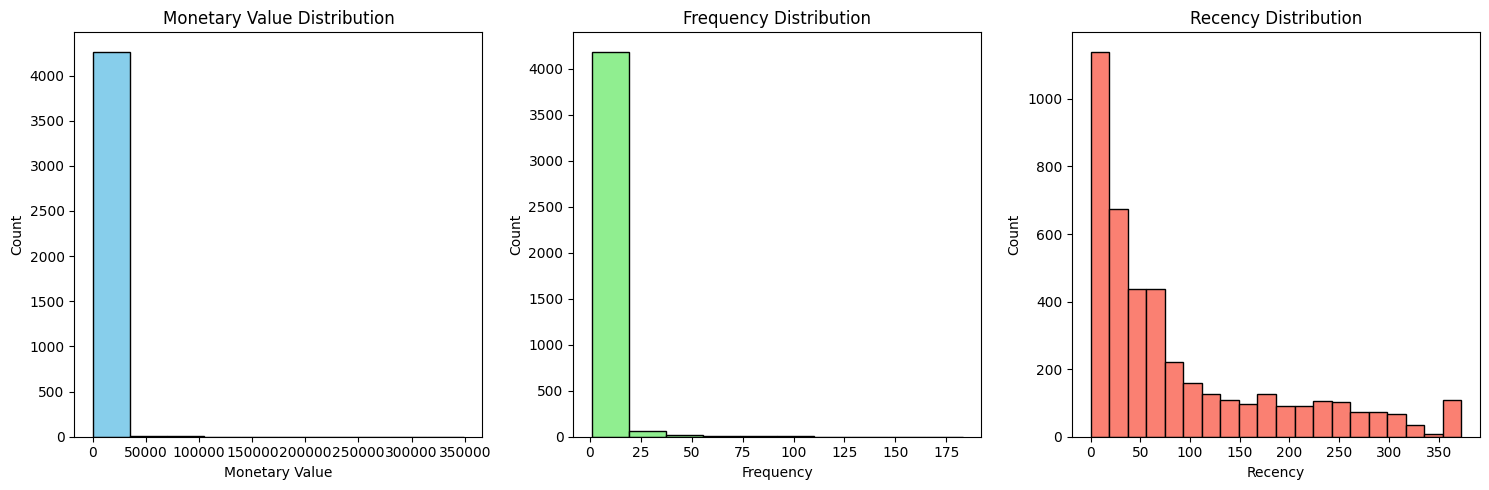

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(aggregated_df['MonetaryValue'], bins=10, color='skyblue', edgecolor='black')
plt.title('Monetary Value Distribution')
plt.xlabel('Monetary Value')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
plt.hist(aggregated_df['Frequency'], bins=10, color='lightgreen', edgecolor='black')
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
plt.hist(aggregated_df['Recency'], bins=20, color='salmon', edgecolor='black')
plt.title('Recency Distribution')
plt.xlabel('Recency')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

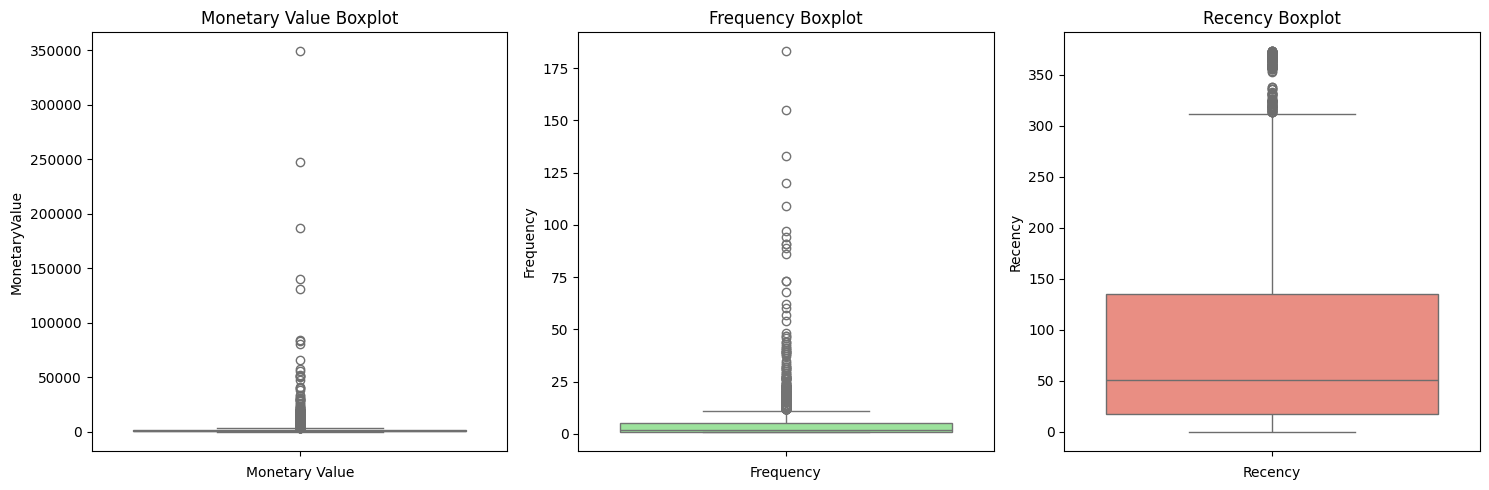

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=aggregated_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=aggregated_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=aggregated_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

In [23]:
M_Q1=aggregated_df["MonetaryValue"].quantile(0.25)
M_Q3=aggregated_df["MonetaryValue"].quantile(0.75)
M_IQR=M_Q3-M_Q1

monetary_outliers_df=aggregated_df[(aggregated_df["MonetaryValue"]<M_Q1-1.5*M_IQR) | (aggregated_df["MonetaryValue"]>M_Q3+1.5*M_IQR)].copy()
monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency
count,423.00,423.00,423.00,423,423.00
mean,15103.04,12188.10,17.17,2010-11-09 12:26:02.978723328,30.04
min,12357.00,3802.04,1.00,2009-12-10 18:03:00,0.00
25%,13622.00,4605.94,8.00,2010-11-08 13:17:30,3.00
50%,14961.00,6191.32,12.00,2010-11-26 12:19:00,13.00
75%,16692.00,10273.24,18.00,2010-12-06 10:34:30,31.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,364.00
std,1728.66,25830.85,19.73,NaN,51.54


In [24]:
F_Q1=aggregated_df["Frequency"].quantile(0.25)
F_Q3=aggregated_df["Frequency"].quantile(0.75)
F_IQR=F_Q3-F_Q1
frequency_outliers_df=aggregated_df[(aggregated_df["Frequency"]<F_Q1-1.5*F_IQR) | (aggregated_df["Frequency"]>F_Q3+1.5*F_IQR)].copy()
frequency_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency
count,279.00,279.00,279.00,279,279.00
mean,15352.66,14409.71,23.81,2010-11-23 11:06:20.645161216,16.09
min,12437.00,1094.39,12.00,2010-05-12 16:51:00,0.00
25%,13800.00,4331.56,13.00,2010-11-20 13:14:30,2.00
50%,15465.00,6615.77,17.00,2010-12-02 10:46:00,7.00
75%,16828.50,11692.41,23.00,2010-12-07 11:08:30,19.00
max,18260.00,349164.35,183.00,2010-12-09 19:32:00,211.00
std,1748.43,31381.74,21.93,NaN,26.59


In [25]:
non_outliers_df=aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers_df.index))].copy()
non_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency
count,3809.00,3809.00,3809.00,3809,3809.00
mean,15376.48,885.50,2.86,2010-09-03 11:16:46.516146176,97.08
min,12346.00,1.55,1.00,2009-12-01 10:49:00,0.00
25%,13912.00,279.91,1.00,2010-07-08 14:48:00,22.00
50%,15389.00,588.05,2.00,2010-10-12 16:25:00,58.00
75%,16854.00,1269.05,4.00,2010-11-17 13:14:00,154.00
max,18287.00,3788.21,11.00,2010-12-09 20:01:00,373.00
std,1693.20,817.67,2.24,NaN,98.11


<H1>CLEANED DATA<H1>

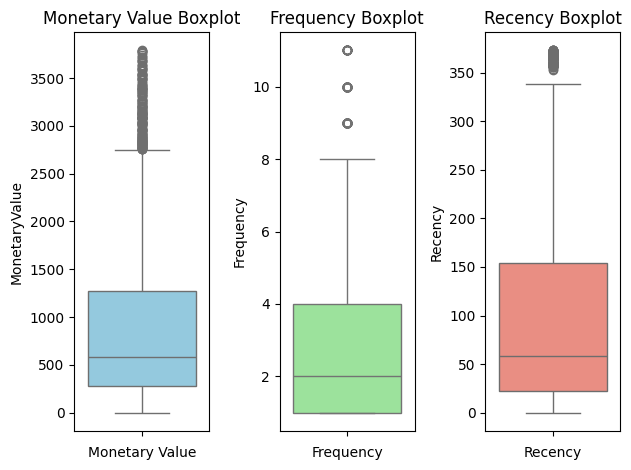

In [26]:
plt.Figure(figsize=(15,5))

plt.subplot(1, 3, 1)
sns.boxplot(data=non_outliers_df['MonetaryValue'], color='skyblue')
plt.title('Monetary Value Boxplot')
plt.xlabel('Monetary Value')

plt.subplot(1, 3, 2)
sns.boxplot(data=non_outliers_df['Frequency'], color='lightgreen')
plt.title('Frequency Boxplot')
plt.xlabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(data=non_outliers_df['Recency'], color='salmon')
plt.title('Recency Boxplot')
plt.xlabel('Recency')

plt.tight_layout()
plt.show()

still a lot of data is looking as outlier but now box plot is looking much better

<Axes3D: title={'center': '3D Scatter Plot of RFM Variables'}, xlabel='Recency', ylabel='Frequency', zlabel='Monetary Value'>

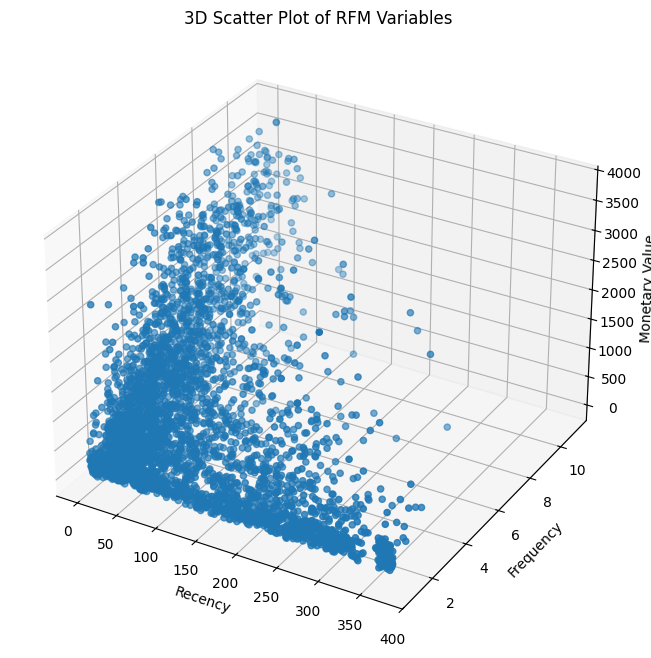

In [27]:
fig = plt.figure(figsize=(8,8))

ax =fig.add_subplot( projection='3d')

scatter = ax.scatter(non_outliers_df['Recency'], non_outliers_df['Frequency'], non_outliers_df['MonetaryValue'],colorizer='blue', marker='o')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')
ax.set_title('3D Scatter Plot of RFM Variables')
ax

<h1>STANDARDISATION</h1>

<body>KNN is really scale sensitive and can give false result , so we want all points to get similar weigtage in the modeling.</body>

In [28]:
scaler= StandardScaler()

scaled_data = scaler.fit_transform(non_outliers_df[['Recency', 'Frequency', 'MonetaryValue']])

scaled_data

array([[ 0.68214853, -0.38488934, -0.87594534],
       [-0.96925093, -0.38488934,  0.5355144 ],
       [-0.24548944, -0.83063076, -0.81258645],
       ...,
       [ 2.01753946, -0.83063076, -0.62197163],
       [ 0.14187587, -0.38488934,  0.44146683],
       [-0.81634357,  0.50659348,  1.72488781]], shape=(3809, 3))

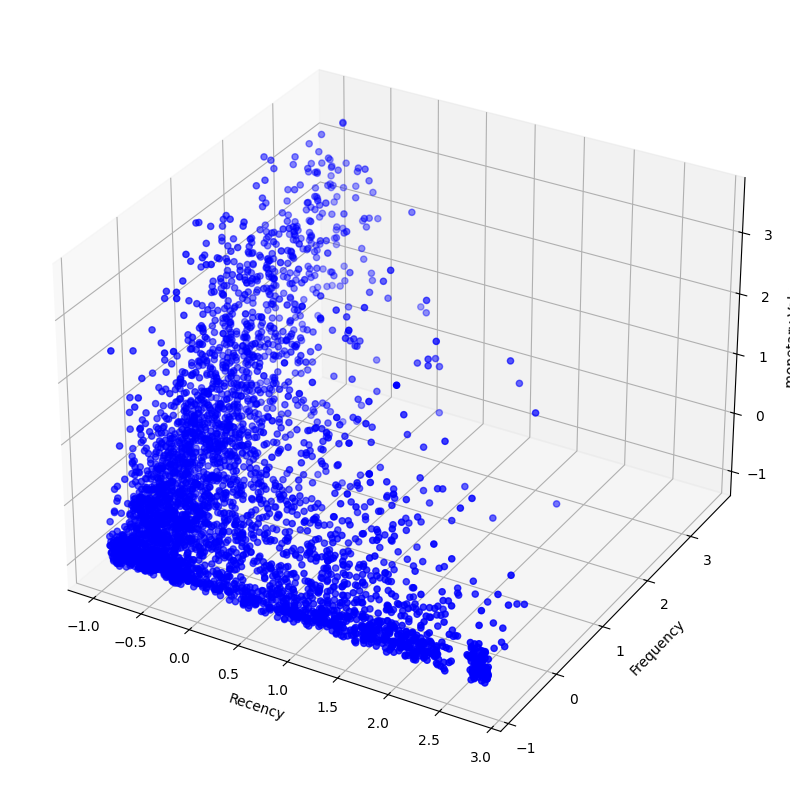

In [29]:
plot = plt.figure(figsize=(10,10))
ax = plot.add_subplot(projection='3d')
ax.scatter(xs=scaled_data[:, 0],   ys=scaled_data[:, 1],zs=scaled_data[:, 2], color='blue', marker='o')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('monetary Value')

plt.show()
  

In [30]:
scaled_data_df=pd.DataFrame(scaled_data,index=non_outliers_df.index,  columns=['Recency', 'Frequency', 'MonetaryValue'])
scaled_data_df

,Recency,Frequency,MonetaryValue
0,0.68,-0.38,-0.88
1,-0.97,-0.38,0.54
2,-0.25,-0.83,-0.81
3,-0.56,-0.38,1.63
4,-0.89,-0.83,-0.72
...,...,...,...
4280,-0.82,1.40,-0.30
4281,-0.32,-0.83,-0.58
4282,2.02,-0.83,-0.62
4283,0.14,-0.38,0.44


<h1>K means clustering </h1>

chosing the number of appropriate cluster,elbow technique and silouette score

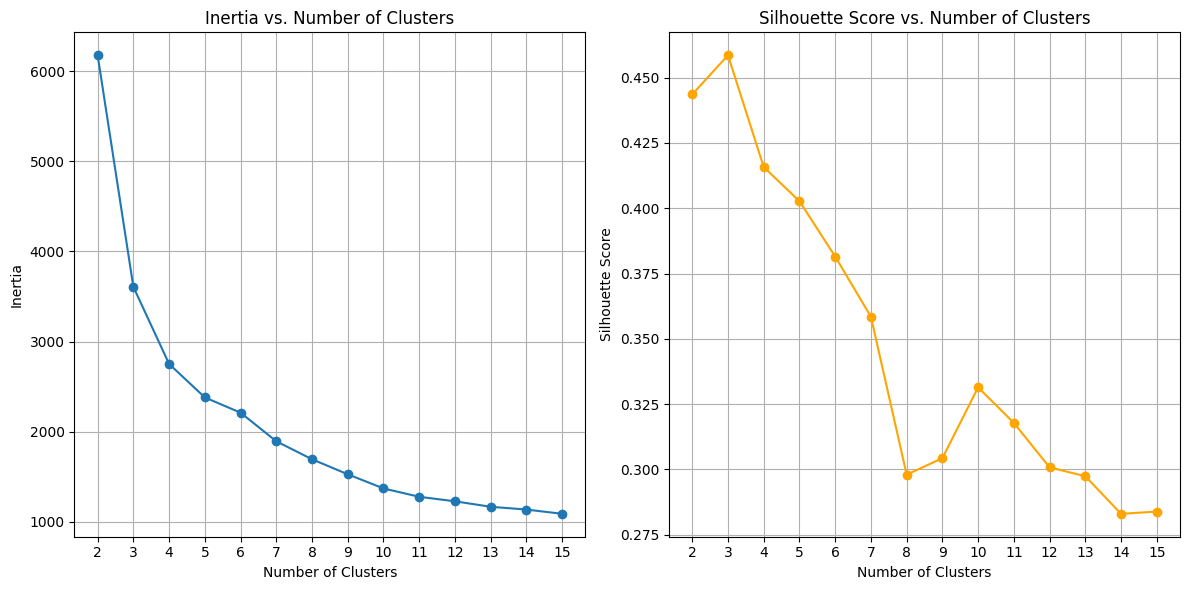

In [31]:
max_K=15
inertia_list = []
silhouette_scores = []
k_value = range(2, max_K + 1) #doesnt make sense to have 1 cluster

for k in k_value:
    kmeans = KMeans(n_clusters=k, random_state=42)#random _state is used for reproducibility(otherwise it will give different results each time)
    cluster_labels= kmeans.fit_predict(scaled_data_df)#gives me cluster labels for each point(only predicts the cluster labels, does not learn the model)
    sil_score= silhouette_score(scaled_data_df,cluster_labels )#silhouette score is used to measure how similar a point is to its own cluster compared to other cluster
    inertia_list.append(kmeans.inertia_)
    silhouette_scores.append(sil_score)
    
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(k_value, inertia_list, marker='o')
plt.title('Inertia vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_value)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(k_value, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_value)
plt.grid()
plt.tight_layout()
plt.show()

In [32]:
kmeans = KMeans(n_clusters=5, random_state=42)  
cluster_labels= kmeans.fit_predict(scaled_data_df)
non_outliers_df["Cluster"] = cluster_labels
cluster_labels
non_outliers_df.head(5)

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,4
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2


<h1>VISUALIZATION</h1>

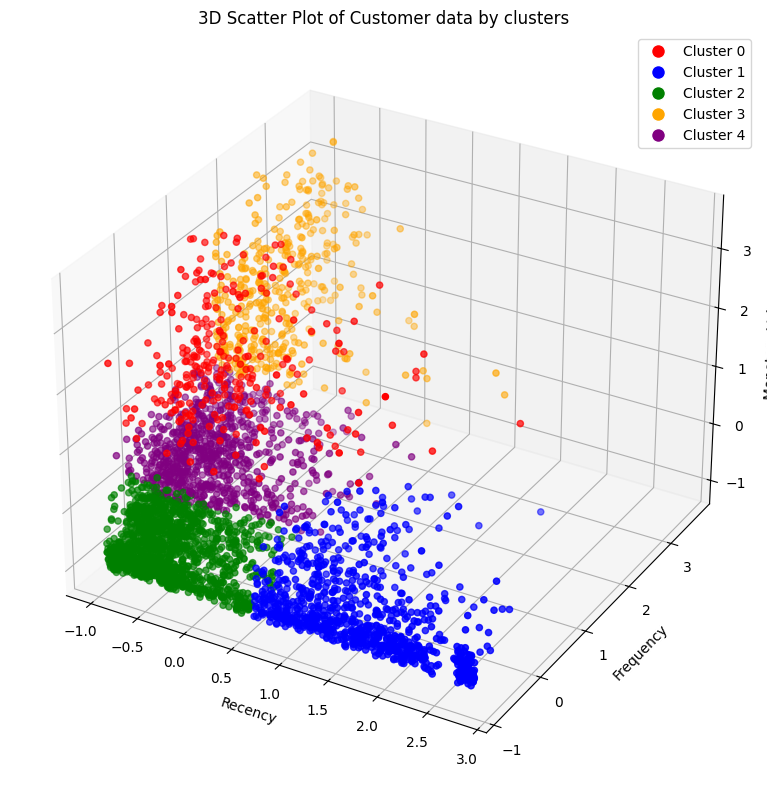

In [33]:
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'purple'}

colors=non_outliers_df['Cluster'].map(cluster_colors)

fig=plt.figure(figsize=(10, 8))
ax = fig.add_subplot( projection='3d')

scatter = ax.scatter(xs=scaled_data_df['Recency'], ys=scaled_data_df['Frequency'], zs=scaled_data_df['MonetaryValue'], c=colors, marker='o')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary Value')
plt.title('3D Scatter Plot of Customer data by clusters')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Cluster {i}') for i, color in cluster_colors.items()])
plt.tight_layout()
plt.show()

<h1>ANALYSIS OF THE RESULT</h1>

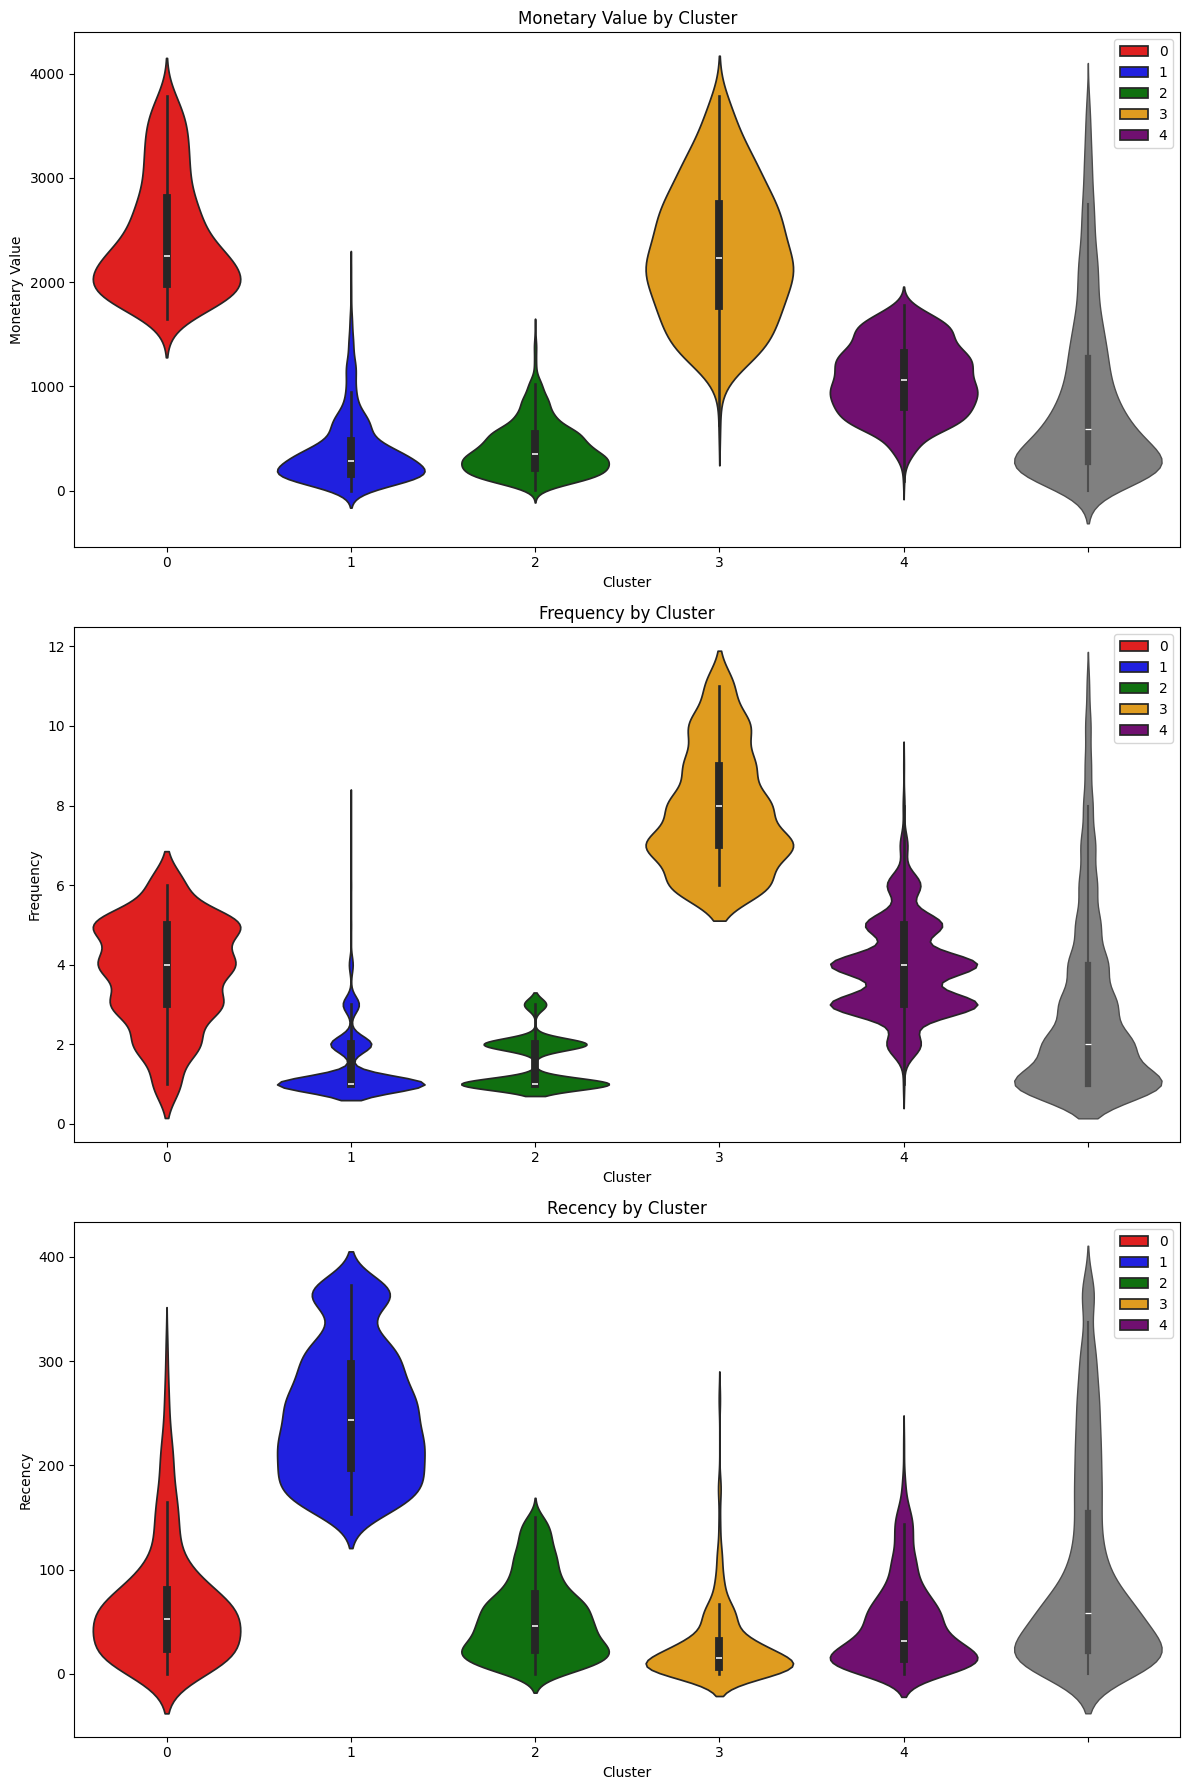

In [34]:
plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['MonetaryValue'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Frequency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')


plt.subplot(3, 1, 3)
sns.violinplot(x=non_outliers_df['Cluster'], y=non_outliers_df['Recency'], palette=cluster_colors, hue=non_outliers_df["Cluster"])
sns.violinplot(y=non_outliers_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

## Cluster-Based Customer Strategy



### Cluster 0 (Red): "Reward"
**Rationale:**  
This group consists of customers with high monetary value, moderate-to-high purchase frequency, and very recent activity. They are your most loyal and valuable segment.

**Action:**  
- Launch loyalty programs and exclusive offers.
- Provide early access to new products or features.
- Send appreciation messages and request referrals.

### Cluster 1 (Blue): "Re-Engage"
**Rationale:**  
These customers have low monetary value, low frequency, and have not purchased recently. They are at risk of being lost.

**Action:**  
- Send targeted win-back campaigns with special discounts.
- Use personalized reminders and recommendations.
- Survey to understand their inactivity and address concerns.

### Cluster 2 (Green): "Nurture"
**Rationale:**  
This segment shows low-to-mid monetary value, low frequency, but recent purchases—often new or infrequent buyers who need encouragement to engage more.

**Action:**  
- Welcome with onboarding emails and product guides.
- Offer incentives for a second purchase.
- Provide excellent customer support to build trust.

### Cluster 3 (Orange): "Retain"
**Rationale:**  
High-value, high-frequency, and very recent customers—these are VIPs who are highly engaged.

**Action:**  
- Treat as VIPs with exclusive deals and personalized service.
- Recognize their loyalty and request testimonials.
- Maintain frequent, high-value engagement.

### Cluster 4 (Purple/Grey): "Encourage"
**Rationale:**  
Customers with moderate value and frequency, and recent activity. They are engaged but have room to grow in value.

**Action:**  
- Use bundle offers or volume discounts.
- Nurture with loyalty points or tiered rewards.
- Send personalized product recommendations.

## Summary Table

| Cluster | Color        | Strategy    | Rationale                                      | Action Summary                          |
|---------|-------------|-------------|------------------------------------------------|-----------------------------------------|
| 0       | Red         | Reward      | Loyal, high value, recent, frequent buyers     | Loyalty programs, exclusives, referrals |
| 1       | Blue        | Re-Engage   | Lapsed, low value, low frequency               | Win-back offers, reminders, surveys     |
| 2       | Green       | Nurture     | New/infrequent, recent, low-mid value          | Onboarding, incentives, support         |
| 3       | Orange      | Retain      | VIP, high value, very frequent, very recent    | VIP treatment, exclusives, recognition  |
| 4       | Purple/Grey | Encourage   | Moderate value and frequency, recent           | Bundles, loyalty, recommendations       |


<h1>Analysis of outlier data</h1>

In [35]:
overlap_indices = monetary_outliers_df.index.intersection(frequency_outliers_df.index)

monetary_only_outliers = monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers = frequency_outliers_df.drop(overlap_indices)
monetary_and_frequency_outliers = monetary_outliers_df.loc[overlap_indices]

monetary_only_outliers["Cluster"] = -1
frequency_only_outliers["Cluster"] = -2
monetary_and_frequency_outliers["Cluster"] = -3

outlier_clusters_df = pd.concat([monetary_only_outliers, frequency_only_outliers, monetary_and_frequency_outliers])

outlier_clusters_df

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency,Cluster
9,12357.00,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.00,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.00,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.00,19468.84,4,2010-11-29 15:07:00,10,-1
61,12431.00,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


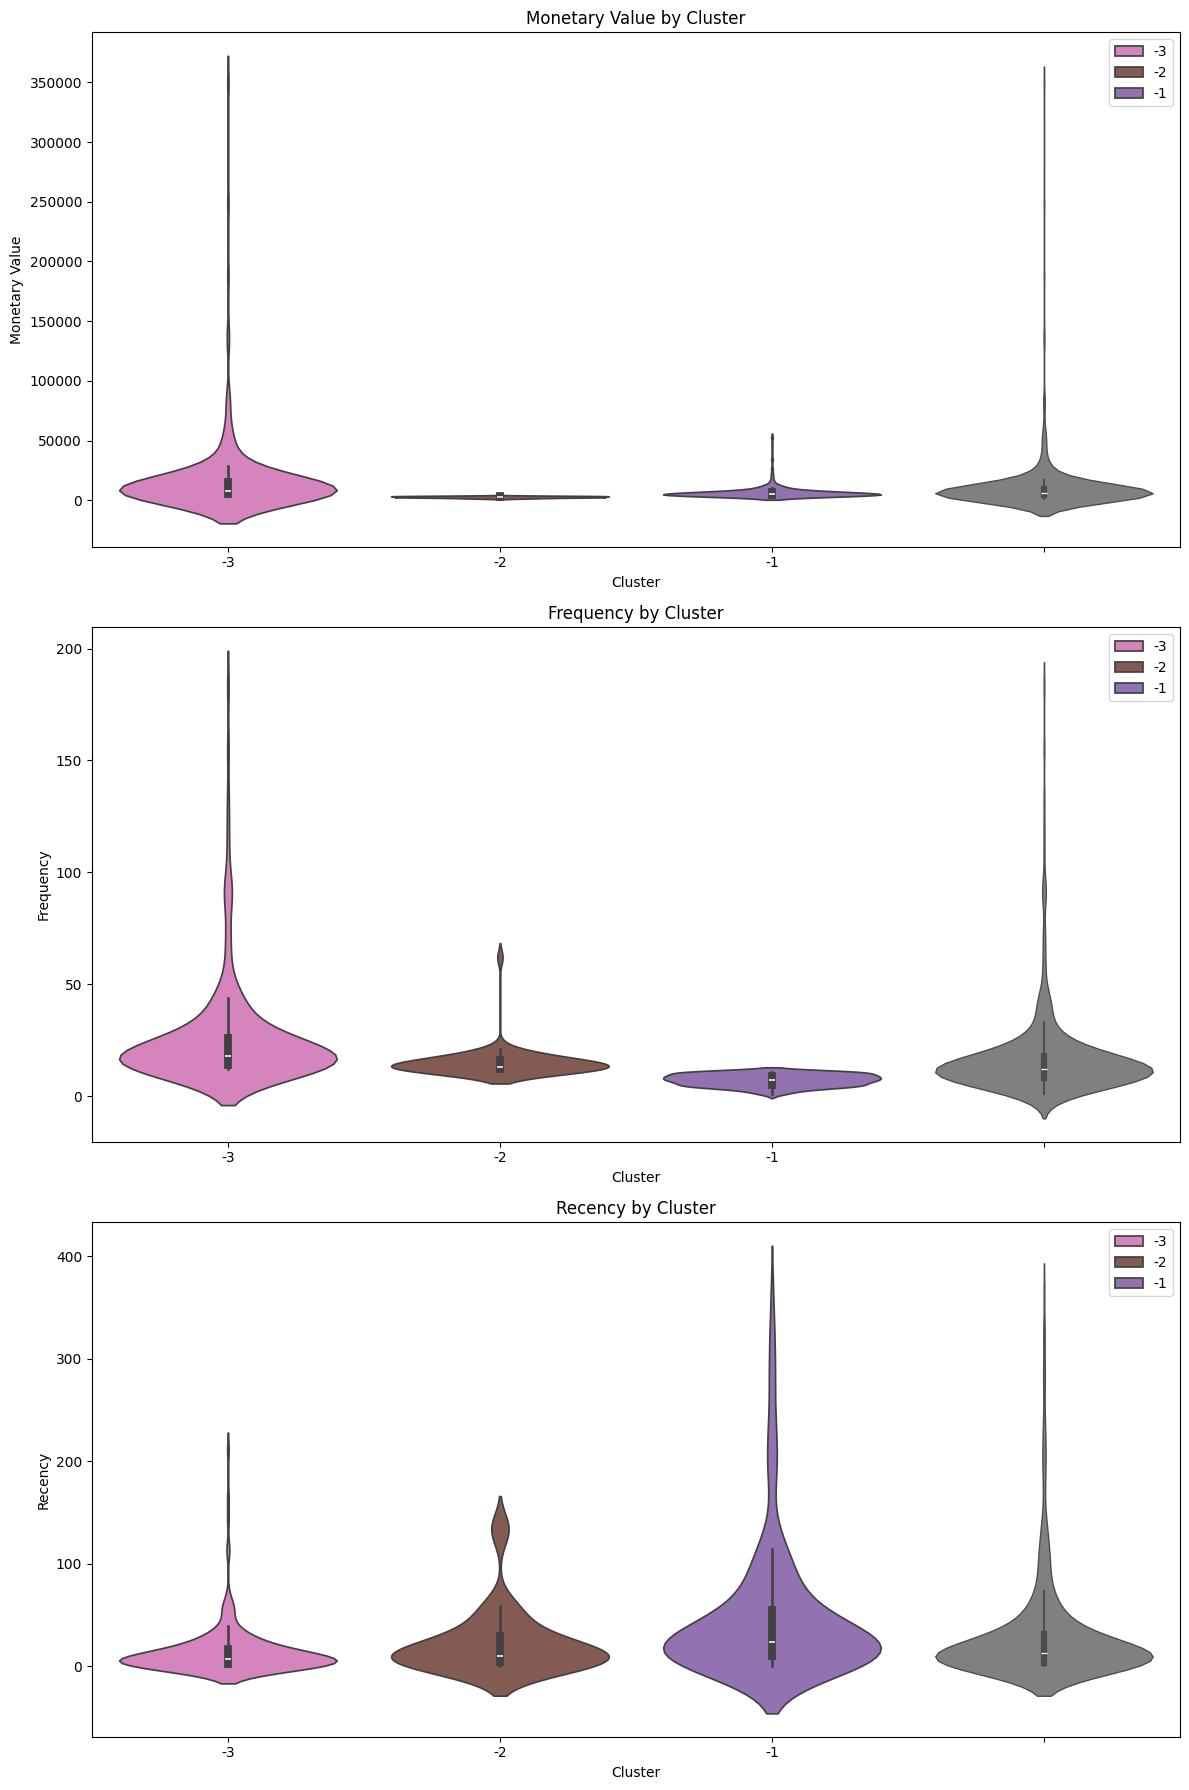

In [36]:
cluster_colors = {-1: '#9467bd',
                  -2: '#8c564b',
                  -3: '#e377c2'}

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['MonetaryValue'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['MonetaryValue'], color='gray', linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3, 1, 2)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Frequency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Frequency'], color='gray', linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3, 1, 3)
sns.violinplot(x=outlier_clusters_df['Cluster'], y=outlier_clusters_df['Recency'], palette=cluster_colors, hue=outlier_clusters_df["Cluster"])
sns.violinplot(y=outlier_clusters_df['Recency'], color='gray', linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

Cluster -1 (Monetary Outliers) PAMPER: Characteristics: High spenders but not necessarily frequent buyers. Their purchases are large but infrequent. Potential Strategy: Focus on maintaining their loyalty with personalized offers or luxury services that cater to their high spending capacity.

Cluster -2 (Frequency Outliers) UPSELL: Characteristics: Frequent buyers who spend less per purchase. These customers are consistently engaged but might benefit from upselling opportunities. Potential Strategy: Implement loyalty programs or bundle deals to encourage higher spending per visit, given their frequent engagement.

Cluster -3 (Monetary & Frequency Outliers) DELIGHT: Characteristics: The most valuable outliers, with extreme spending and frequent purchases. They are likely your top-tier customers who require special attention. Potential Strategy: Develop VIP programs or exclusive offers to maintain their loyalty and encourage continued engagement.

In [37]:
cluster_labels = {
    0: "REWARD",
    1: "RE-ENGAGE",
    2: "NURTURE",
    3: "RETAIN",
    4: "ENCOURAGE",
    -1: "PAMPER",
    -2: "UPSELL",
    -3: "DELIGHT"
}

In [38]:
full_clustering_df = pd.concat([non_outliers_df, outlier_clusters_df])

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency,Cluster
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,4
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2
...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3


In [39]:
full_clustering_df["ClusterLabel"] = full_clustering_df["Cluster"].map(cluster_labels)

full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastPurchaseDate,Recency,Cluster,ClusterLabel
0,12346.00,169.36,2,2010-06-28 13:53:00,164,1,RE-ENGAGE
1,12347.00,1323.32,2,2010-12-07 14:57:00,2,4,ENCOURAGE
2,12348.00,221.16,1,2010-09-27 14:59:00,73,2,NURTURE
3,12349.00,2221.14,2,2010-10-28 08:23:00,42,0,REWARD
4,12351.00,300.93,1,2010-11-29 15:23:00,10,2,NURTURE
...,...,...,...,...,...,...,...
4235,18223.00,7516.31,12,2010-11-17 12:20:00,22,-3,DELIGHT
4236,18225.00,7545.14,15,2010-12-09 15:46:00,0,-3,DELIGHT
4237,18226.00,6650.83,15,2010-11-26 15:51:00,13,-3,DELIGHT
4241,18231.00,4791.80,23,2010-10-29 14:17:00,41,-3,DELIGHT


<h1>VISUALISATION</h1>

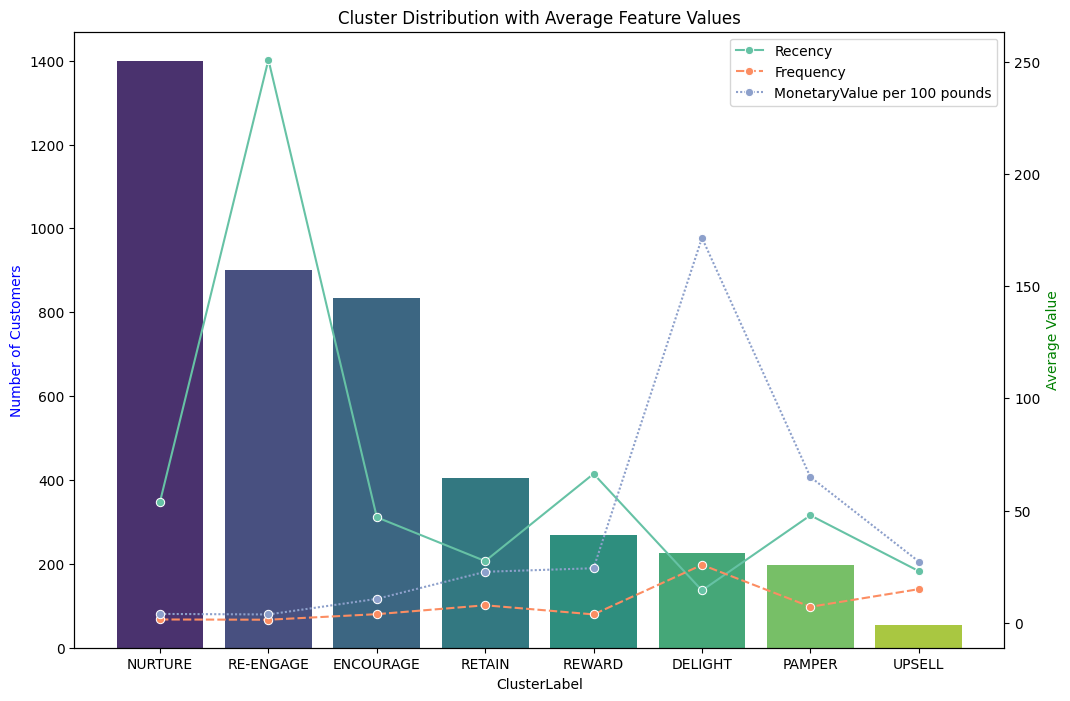

In [40]:
cluster_counts = full_clustering_df['ClusterLabel'].value_counts()
full_clustering_df["MonetaryValue per 100 pounds"] = full_clustering_df["MonetaryValue"] / 100.00
feature_means = full_clustering_df.groupby('ClusterLabel')[['Recency', 'Frequency', 'MonetaryValue per 100 pounds']].mean()

fig, ax1 = plt.subplots(figsize=(12, 8))

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=ax1, palette='viridis', hue=cluster_counts.index)
ax1.set_ylabel('Number of Customers', color='b')
ax1.set_title('Cluster Distribution with Average Feature Values')

ax2 = ax1.twinx()

sns.lineplot(data=feature_means, ax=ax2, palette='Set2', marker='o')
ax2.set_ylabel('Average Value', color='g')

plt.show()